In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install plotly
!pip install openpyxl


In [1]:
import pandas as hm  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
import plotly.express as px 
import plotly.graph_objects as go 
from plotly.subplots import make_subplots 

import warnings 
warnings.filterwarnings('ignore') 
sns.set_style('whitegrid') 
plt.rcParams['figure.figsize'] = (10, 5) 
print('Libraries imported successfully!')



Libraries imported successfully!


In [2]:
import pandas as hm
hm = hm.read_excel("sales_records_dataset.xlsx") 
print(f'Dataset loaded! Shape: {hm.shape[0]} rows × {hm.shape[1]} columns') 

hm.head()

Dataset loaded! Shape: 1000 rows × 14 columns


,Order_ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D
1,NaN,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C
3,ORD1004,Daniel Balogun,Female,East,Furniture,Bed,5.0,102967.0,514835.0,3286.0,87530.327068,NaN,Cash,Rep_B
4,ORD1005,Ibrahim Khan,Male,West,Electronics,Laptop,7.0,148887.0,1042209.0,741.0,67011.935599,2022-06-03,Transfer,Rep_D


In [3]:
hm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          955 non-null    object 
 1   Customer_Name     956 non-null    object 
 2   Gender            949 non-null    object 
 3   Region            941 non-null    object 
 4   Product_Category  944 non-null    object 
 5   Product_Name      961 non-null    object 
 6   Quantity          955 non-null    float64
 7   Unit_Price        949 non-null    float64
 8   Total_Sales       942 non-null    float64
 9   Discount          950 non-null    float64
 10  Profit            947 non-null    float64
 11  Order_Date        945 non-null    object 
 12  Payment_Method    944 non-null    object 
 13  Sales_Rep         955 non-null    object 
dtypes: float64(5), object(9)
memory usage: 109.5+ KB


In [4]:
hm.describe().round(2)

,Quantity,Unit_Price,Total_Sales,Discount,Profit
count,955.00,949.00,942.00,950.00,947.00
mean,5.53,75752.28,424735.26,2513.22,64645.40
std,2.85,42736.95,339359.57,1463.39,61028.39
min,1.00,2037.00,2118.00,0.00,171.57
25%,3.00,38059.00,133941.50,1271.00,17417.64
50%,6.00,76180.00,357334.50,2497.50,46940.54
75%,8.00,112145.00,621387.25,3796.25,93647.07
max,10.00,149555.00,1492040.00,4996.00,356652.16


In [5]:
import pandas as pd

missing = hm.isnull().sum()
missing_pct = (missing / len(hm) * 100).round(2)

missing_hm = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_hm = missing_hm[missing_hm['Missing Count'] > 0] \
    .sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(missing_hm.to_string())

Columns with missing values:
                  Missing Count  Missing %
Region                       59        5.9
Total_Sales                  58        5.8
Product_Category             56        5.6
Payment_Method               56        5.6
Order_Date                   55        5.5
Profit                       53        5.3
Gender                       51        5.1
Unit_Price                   51        5.1
Discount                     50        5.0
Order_ID                     45        4.5
Quantity                     45        4.5
Sales_Rep                    45        4.5
Customer_Name                44        4.4
Product_Name                 39        3.9


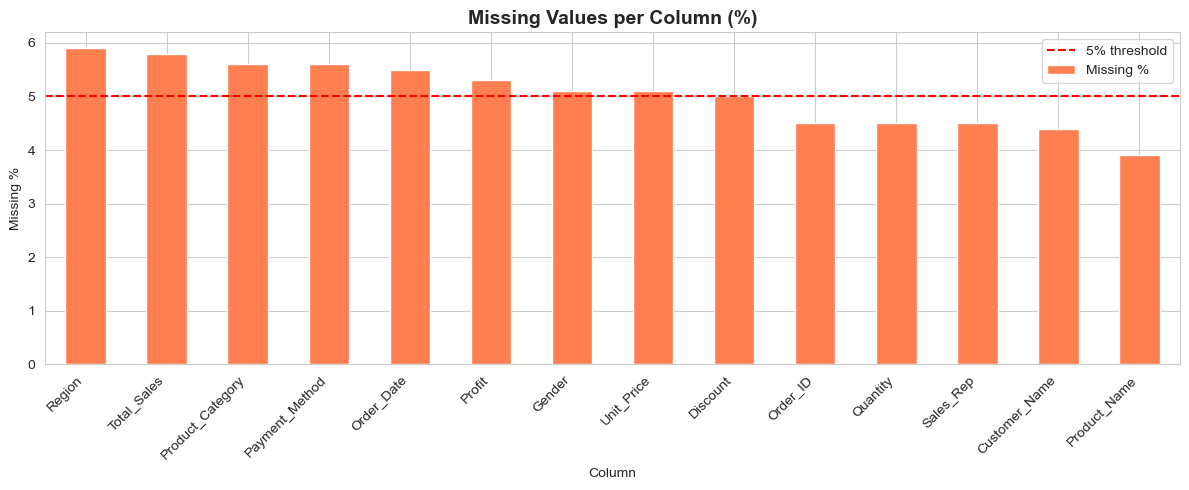

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

missing_hm['Missing %'].plot(kind='bar', color='coral', ax=ax)

ax.set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')

ax.axhline(5, color='red', linestyle='--', label='5% threshold')
ax.legend()

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [8]:
cat_cols = ['Gender', 'Region', 'Product_Category', 'Payment_Method', 'Sales_Rep'] 
for col in cat_cols: 
 print(f'\n�� {col}:') 
 print(hm[col].value_counts(dropna=False).to_string())



�� Gender:
Gender
Female    491
Male      458
NaN        51

�� Region:
Region
South    258
East     239
West     232
North    212
NaN       59

�� Product_Category:
Product_Category
Furniture      208
Electronics    204
Food           202
Clothing       184
Books          146
NaN             56

�� Payment_Method:
Payment_Method
POS         253
Transfer    235
Online      234
Cash        222
NaN          56

�� Sales_Rep:
Sales_Rep
Rep_D    251
Rep_A    249
Rep_C    230
Rep_B    225
NaN       45


In [9]:
hm_clean = hm.copy() 
print(f'Working copy created. Shape: {hm_clean.shape}') 


Working copy created. Shape: (1000, 14)


In [10]:
hm_clean['Order_Date'] = pd.to_datetime(hm_clean['Order_Date'], errors='coerce') 
print('Order_Date dtype after fix:', hm_clean['Order_Date'].dtype)
print('Sample dates:', hm_clean['Order_Date'].dropna().head(5).tolist()) 



Order_Date dtype after fix: datetime64[ns]
Sample dates: [Timestamp('2022-07-18 00:00:00'), Timestamp('2024-09-18 00:00:00'), Timestamp('2023-09-11 00:00:00'), Timestamp('2022-06-03 00:00:00'), Timestamp('2023-07-12 00:00:00')]


In [11]:
before = len(hm_clean) 
hm_clean.drop_duplicates(inplace=True) 
after = len(hm_clean) 
print(f'Rows before: {before} | After: {after} | Removed: {before - after}') 


Rows before: 1000 | After: 1000 | Removed: 0


In [13]:
hm_clean['Quantity'] = hm_clean['Quantity'].fillna(hm_clean['Quantity'].median())

In [14]:
# Fill missing values properly
hm_clean['Unit_Price'] = hm_clean['Unit_Price'].fillna(hm_clean['Unit_Price'].median())

hm_clean['Total_Sales'] = hm_clean['Total_Sales'].fillna(hm_clean['Total_Sales'].median())

hm_clean['Profit'] = hm_clean['Profit'].fillna(hm_clean['Profit'].median())

hm_clean['Discount'] = hm_clean['Discount'].fillna(0)

# Check remaining missing values
print('Numeric columns — remaining missing values:')
print(hm_clean[['Quantity','Unit_Price','Total_Sales','Profit','Discount']].isnull().sum())


Numeric columns — remaining missing values:
Quantity       0
Unit_Price     0
Total_Sales    0
Profit         0
Discount       0
dtype: int64


In [15]:
# Fill categorical columns with mode
for col in ['Gender', 'Region', 'Product_Category', 'Payment_Method']:
    mode_val = hm_clean[col].mode()[0]
    hm_clean[col].fillna(mode_val, inplace=True)

# Fill other text columns with 'Unknown'
for col in ['Sales_Rep', 'Customer_Name', 'Order_ID', 'Product_Name']:
    hm_clean[col].fillna('Unknown', inplace=True)

# Drop rows where Order_Date is missing
hm_clean.dropna(subset=['Order_Date'], inplace=True)

# Check remaining missing values
print('Remaining missing values after cleaning:')
print(hm_clean.isnull().sum())


Remaining missing values after cleaning:
Order_ID            0
Customer_Name       0
Gender              0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Total_Sales         0
Discount            0
Profit              0
Order_Date          0
Payment_Method      0
Sales_Rep           0
dtype: int64


In [16]:
hm_clean['Year'] = hm_clean['Order_Date'].dt.year
hm_clean['Month'] = hm_clean['Order_Date'].dt.month
hm_clean['Month_Name'] = hm_clean['Order_Date'].dt.strftime('%b')
hm_clean['Quarter'] = hm_clean['Order_Date'].dt.to_period('Q').astype(str)

hm_clean['Profit_Margin'] = (
    hm_clean['Profit'] / hm_clean['Total_Sales'] * 100
).round(2)

print('New columns added:', ['Year','Month','Month_Name','Quarter','Profit_Margin'])

print(hm_clean[['Order_Date','Year','Month','Month_Name','Quarter','Profit_Margin']].head())



New columns added: ['Year', 'Month', 'Month_Name', 'Quarter', 'Profit_Margin']
  Order_Date  Year  Month Month_Name Quarter  Profit_Margin
0 2022-07-18  2022      7        Jul  2022Q3          18.19
1 2024-09-18  2024      9        Sep  2024Q3          12.94
2 2023-09-11  2023      9        Sep  2023Q3           5.87
4 2022-06-03  2022      6        Jun  2022Q2           6.43
5 2023-07-12  2023      7        Jul  2023Q3          22.40


In [17]:
print(f'Clean dataset shape: {hm_clean.shape}')
print(f'Rows removed during cleaning: {len(hm) - len(hm_clean)}')

print(hm_clean.head(3))

Clean dataset shape: (945, 19)
Rows removed during cleaning: 55
  Order_ID     Customer_Name  Gender Region Product_Category Product_Name  \
0  ORD1001      Zainab James  Female   West      Electronics       Laptop   
1  Unknown     Zainab Okafor    Male   East         Clothing        Jeans   
2  ORD1003  Samuel Abdullahi    Male  South         Clothing        Shirt   

   Quantity  Unit_Price  Total_Sales  Discount        Profit Order_Date  \
0       3.0     21785.0      65355.0    4346.0  11889.607718 2022-07-18   
1       2.0     69255.0     138510.0     903.0  17920.557815 2024-09-18   
2       9.0    106459.0     958131.0     171.0  56257.963706 2023-09-11   

  Payment_Method Sales_Rep  Year  Month Month_Name Quarter  Profit_Margin  
0           Cash     Rep_D  2022      7        Jul  2022Q3          18.19  
1         Online     Rep_A  2024      9        Sep  2024Q3          12.94  
2            POS     Rep_C  2023      9        Sep  2023Q3           5.87  


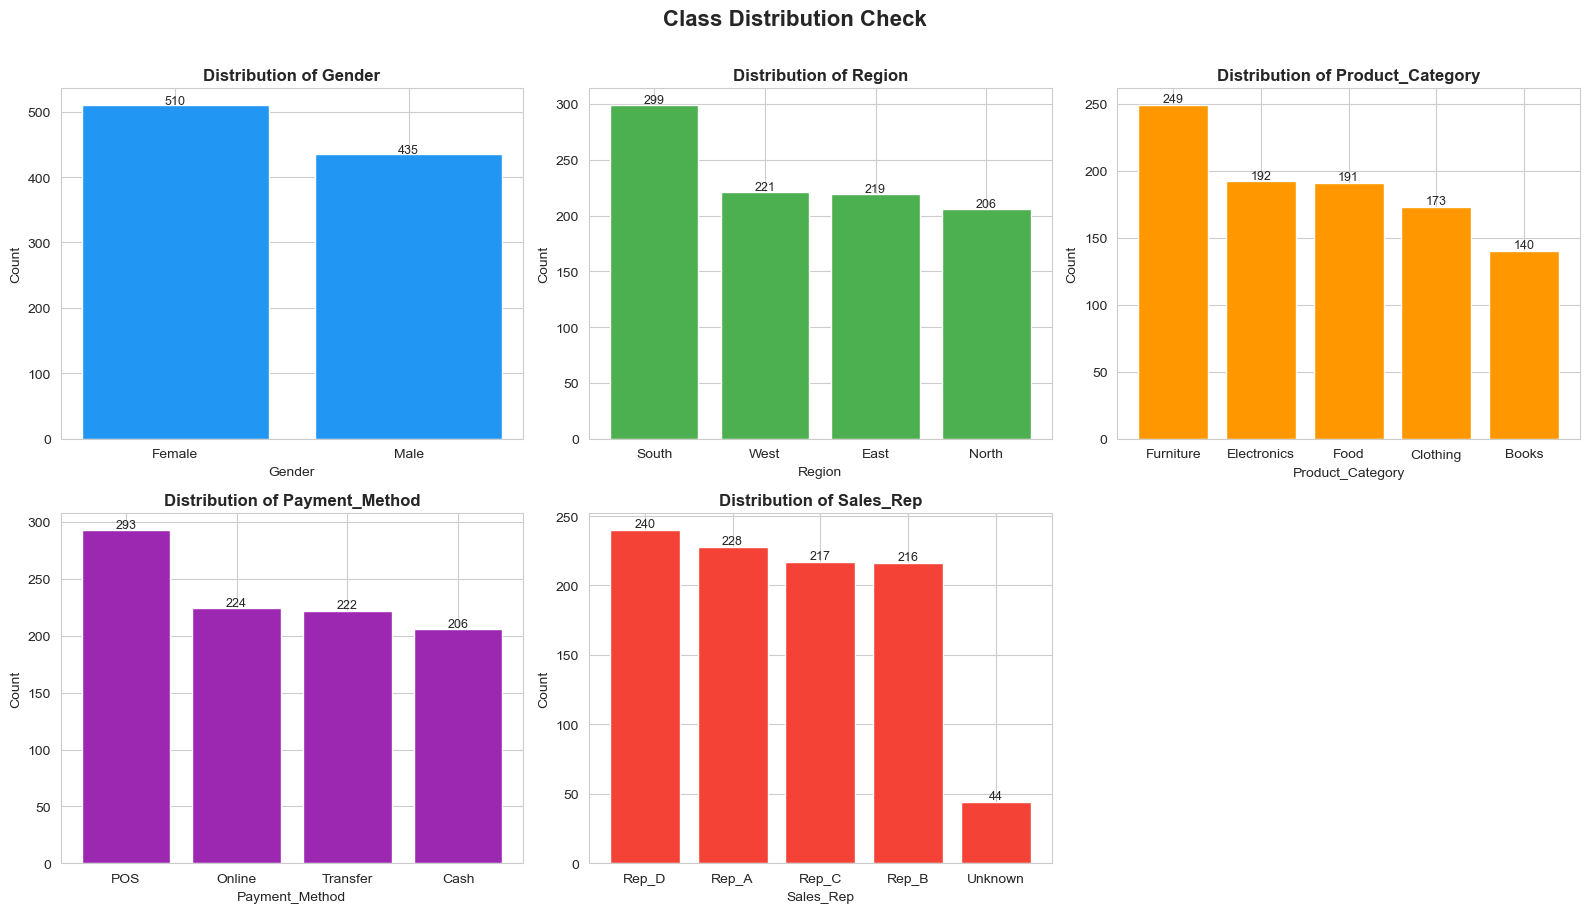

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cat_cols = ['Gender', 'Region', 'Product_Category', 'Payment_Method', 'Sales_Rep']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for i, col in enumerate(cat_cols):
    counts = hm_clean[col].value_counts()

    axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=9)

# Hide last empty subplot
axes[5].set_visible(False)

plt.suptitle('Class Distribution Check', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
print('Imbalance Ratios (max / min count per category)\n') 
for col in cat_cols: 
 counts = hm_clean[col].value_counts() 
 ratio = counts.max() / counts.min() 
 status = 'Balanced' if ratio <= 2.0 else '⚠️ Imbalanced' 
 print(f'{col:<20} Ratio: {ratio:.2f} {status}') 



Imbalance Ratios (max / min count per category)

Gender               Ratio: 1.17 Balanced
Region               Ratio: 1.45 Balanced
Product_Category     Ratio: 1.78 Balanced
Payment_Method       Ratio: 1.42 Balanced
Sales_Rep            Ratio: 5.45 ⚠️ Imbalanced


In [20]:
APPLY_BALANCING = False # Change to True to activate 
BALANCE_COLUMN = 'Sales_Rep' 
if APPLY_BALANCING: 
 min_count = hm_clean[BALANCE_COLUMN].value_counts().min() 
 hm_balanced = ( 
 hm_clean.groupby(BALANCE_COLUMN) 
 .apply(lambda x: x.sample(min_count, random_state=42))  .reset_index(drop=True) 
 ) 
 print(f'Balanced shape: {hm_balanced.shape}') 
 print(hm_balanced[BALANCE_COLUMN].value_counts()) 
else: 
 hm_balanced = hm_clean.copy() 
 print('Using the full cleaned dataset.') 
 print(f'Shape: {hm_balanced.shape}') 


Using the full cleaned dataset.
Shape: (945, 19)


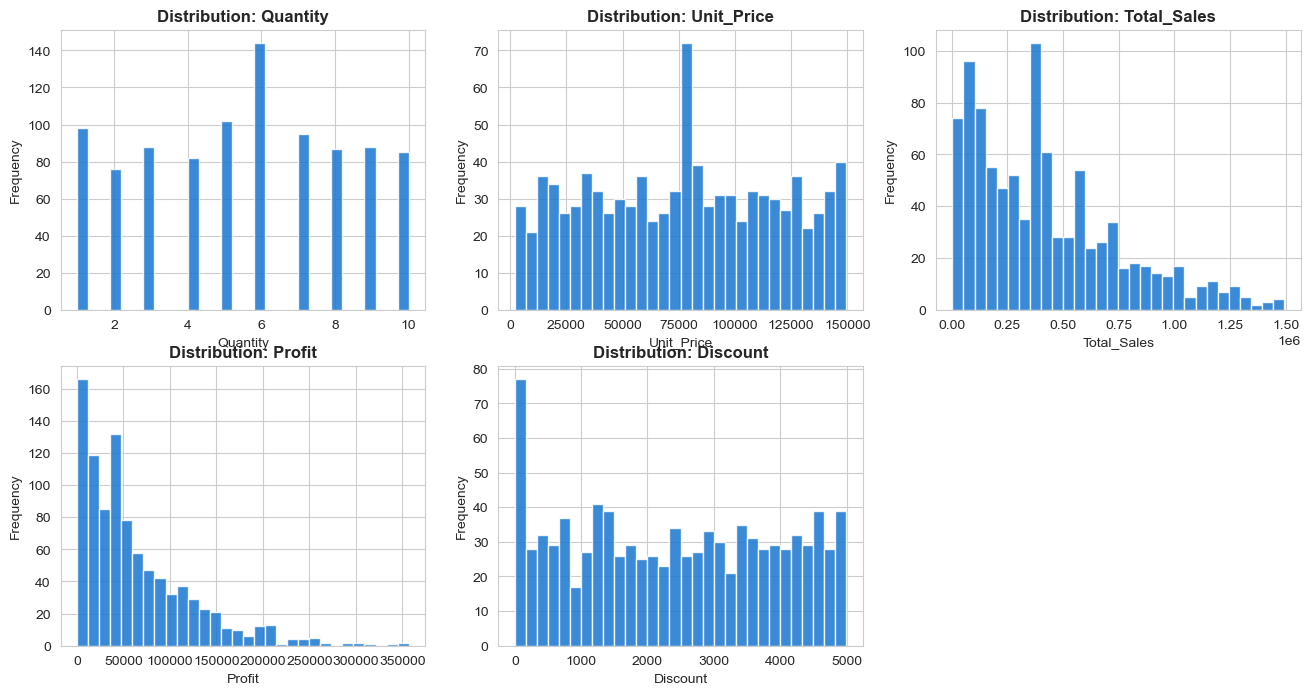

In [21]:
num_cols = ['Quantity', 'Unit_Price', 'Total_Sales', 'Profit', 'Discount'] 
fig, axes = plt.subplots(2, 3, figsize=(16, 8)) 
axes = axes.flatten() 
for i, col in enumerate(num_cols): 
 axes[i].hist(hm_balanced[col], bins=30, color='#1976D2', 
 edgecolor='white', alpha=0.85) 
 axes[i].set_title(f'Distribution: {col}', fontweight='bold') 
 axes[i].set_xlabel(col) 
 axes[i].set_ylabel('Frequency') 
axes[5].set_visible(False) 
# plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold') plt.tight_layout() 
plt.show()


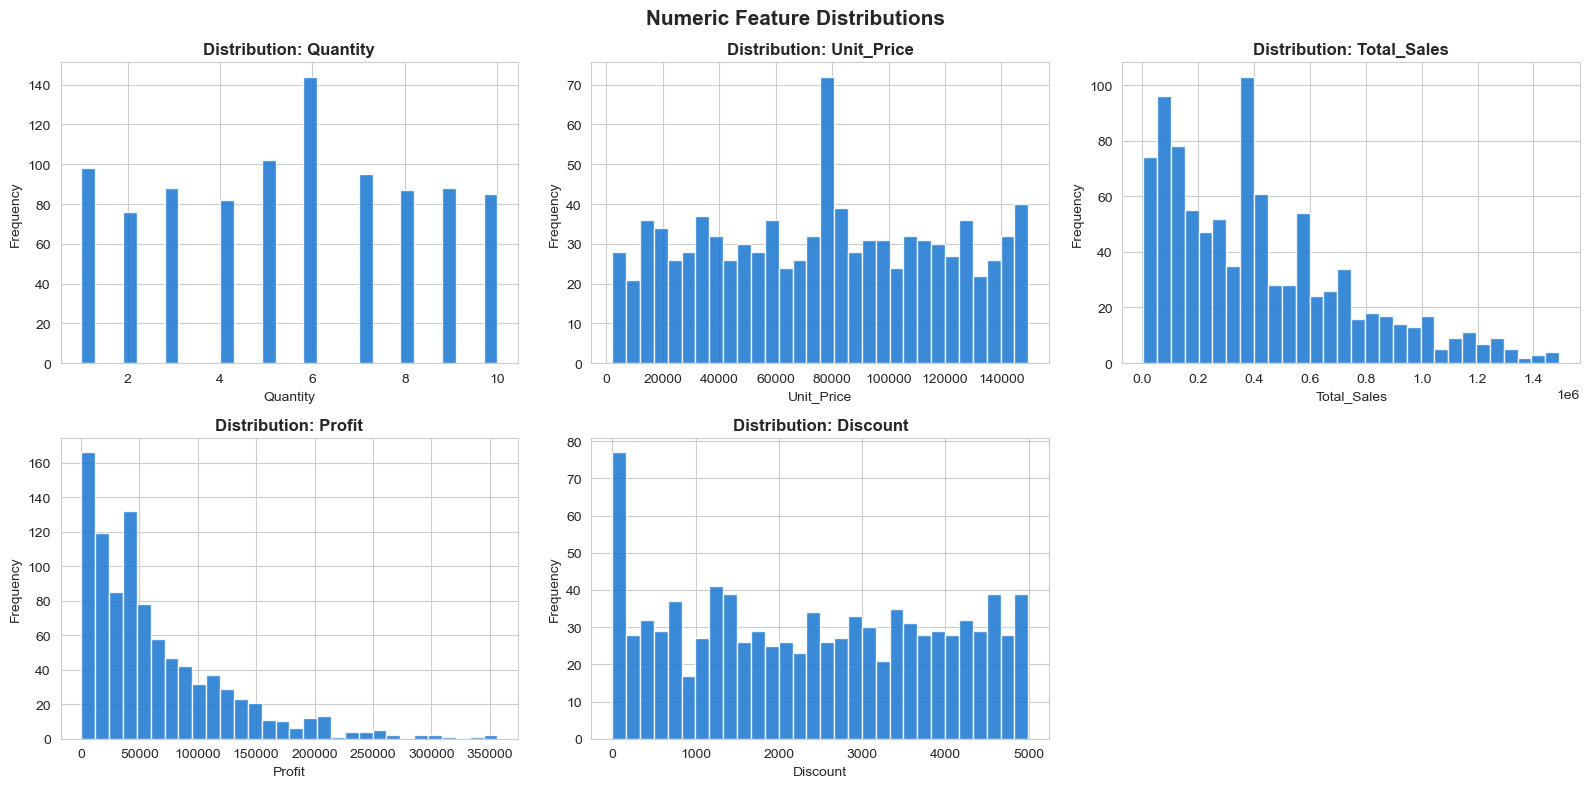

In [22]:
import matplotlib.pyplot as plt

num_cols = ['Quantity', 'Unit_Price', 'Total_Sales', 'Profit', 'Discount']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(
        hm_balanced[col], 
        bins=30, 
        color='#1976D2', 
        edgecolor='white', 
        alpha=0.85
    )
    axes[i].set_title(f'Distribution: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide the last empty subplot
axes[5].set_visible(False)

# Separate lines for each command
plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Revenue by Product Category'}, xlabel='Product_Category'>

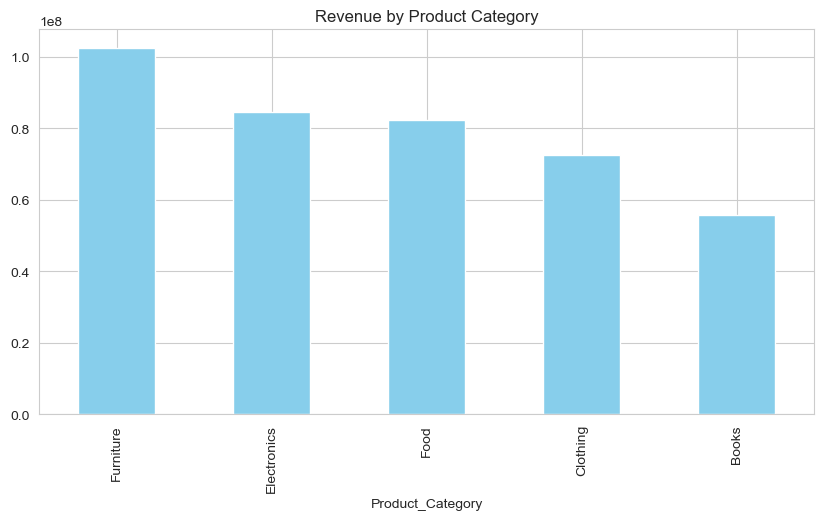

In [23]:
#business question to answer

#1
category_revenue = hm_clean.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar', color='skyblue', title='Revenue by Product Category')

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Order_Date'>

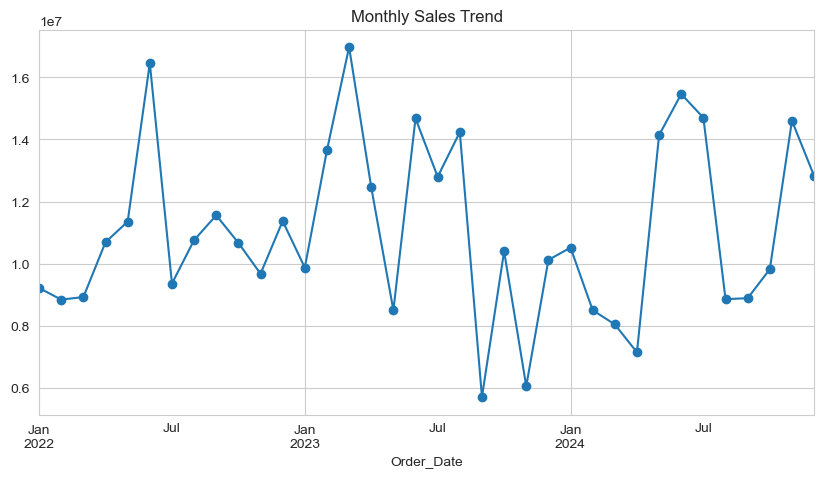

In [24]:
#2
monthly_sales = hm_clean.groupby(hm_clean['Order_Date'].dt.to_period('M'))['Total_Sales'].sum()
monthly_sales.plot(kind='line', marker='o', title='Monthly Sales Trend')

<Axes: title={'center': 'Profit by Region'}, xlabel='Region'>

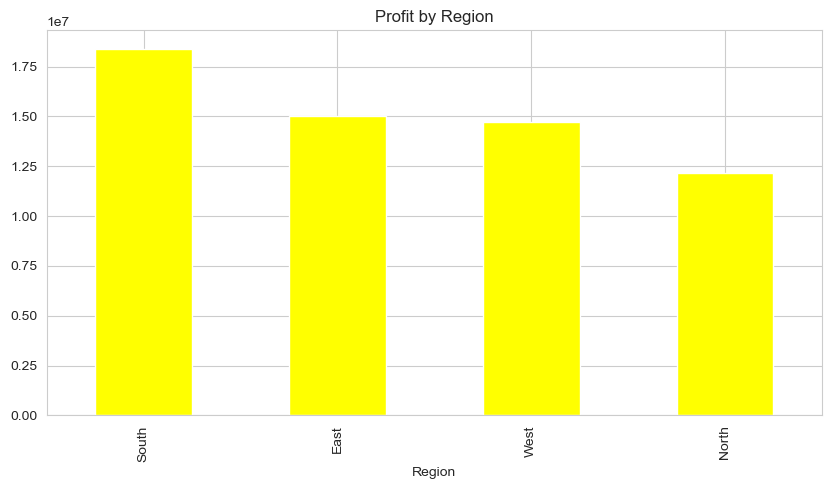

In [25]:
#3
region_profit = hm_clean.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region_profit.plot(kind='bar', color='yellow', title='Profit by Region')


<Axes: title={'center': 'Popular Payment Methods'}, xlabel='Payment_Method'>

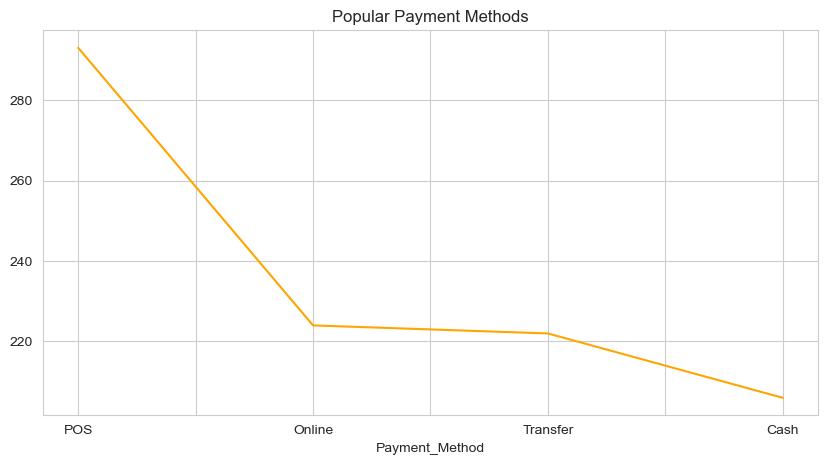

In [26]:
#which payment method is the most popular
#4
hm_clean['Payment_Method'].value_counts().plot(kind='line', color='orange', title='Popular Payment Methods')

<Axes: title={'center': 'Sales by Rep'}, ylabel='Total_Sales'>

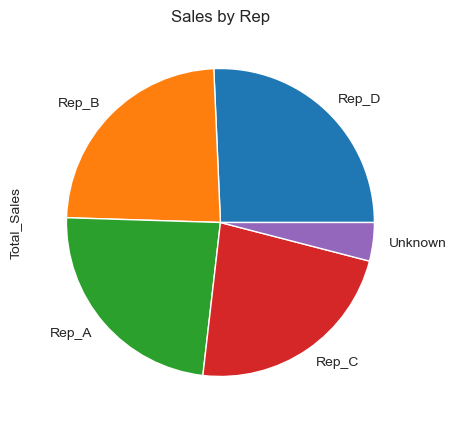

In [27]:
#how do the sales reps compare
#5
rep_performance = hm_clean.groupby('Sales_Rep')['Total_Sales'].sum().sort_values(ascending=False)
rep_performance.plot(kind='pie', color='purple', title='Sales by Rep')

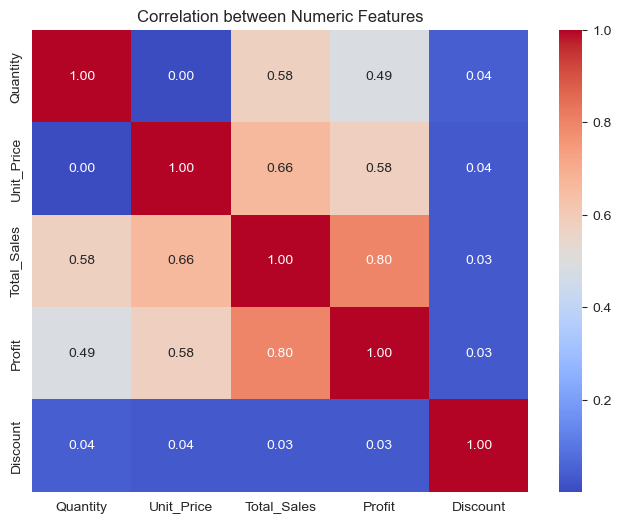

In [28]:
#is there a correlation between the key numeric values?
#6
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure numeric columns
num_cols = ['Quantity','Unit_Price','Total_Sales','Profit','Discount']
hm_clean[num_cols] = hm_clean[num_cols].apply(pd.to_numeric, errors='coerce')

# Compute correlation
corr_matrix = hm_clean[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between Numeric Features')
plt.show()

<Axes: xlabel='Product_Category'>

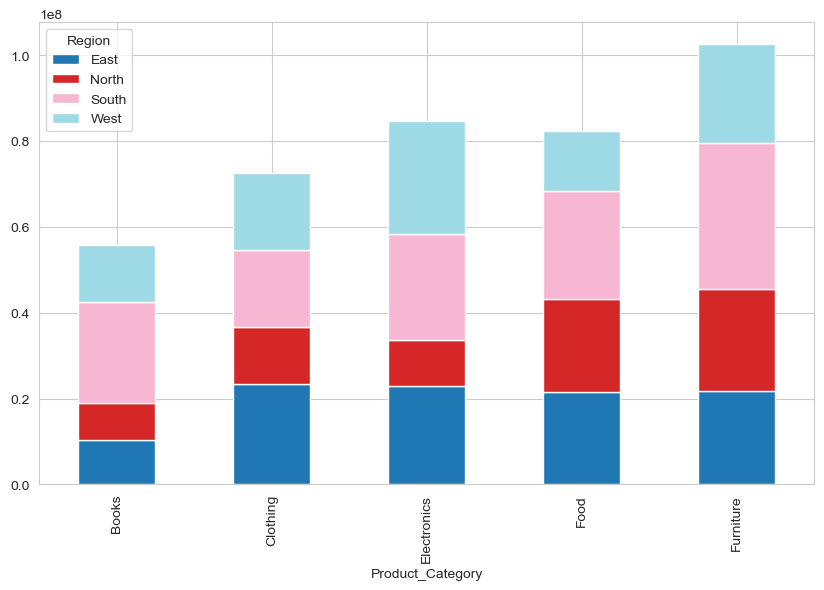

In [29]:
#• What does the sales distribution look like per category and region? 
#7
sales_pivot = hm_clean.pivot_table(values='Total_Sales', index='Product_Category', columns='Region', aggfunc='sum')
sales_pivot.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')


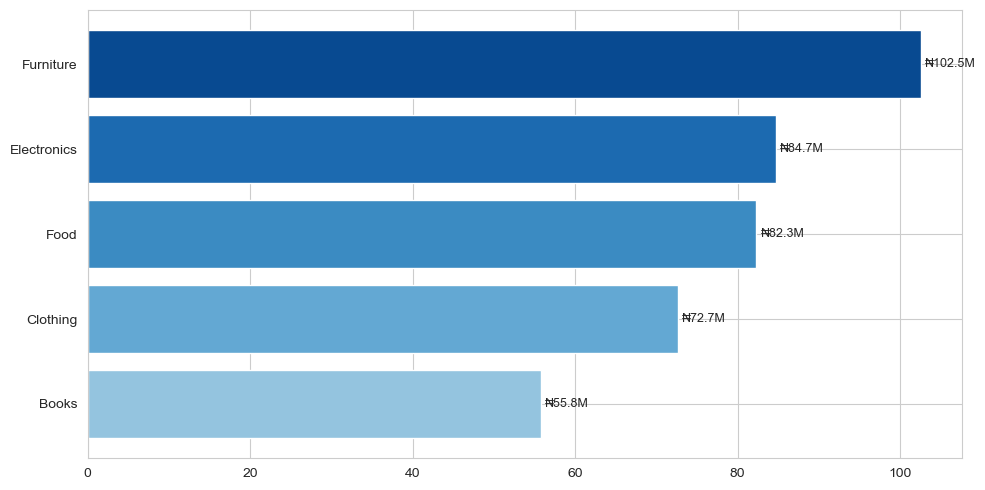

In [69]:
cat_sales = hm_balanced.groupby('Product_Category')['Total_Sales'].sum()  .sort_values(ascending=True) 
fig, ax = plt.subplots(figsize=(10, 5)) 
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_sales))) 
bars = ax.barh(cat_sales.index, cat_sales.values / 1e6, color=colors,  edgecolor='white') 
for bar, val in zip(bars, cat_sales.values): 
 ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,  f'₦{val/1e6:.1f}M', va='center', fontsize=9) 
# ax.set_title('Total Sales by Product Category', fontsize=14, fontweight='bold') ax.set_xlabel('Total Sales (Millions ₦)') 
plt.tight_layout() 
plt.show() 


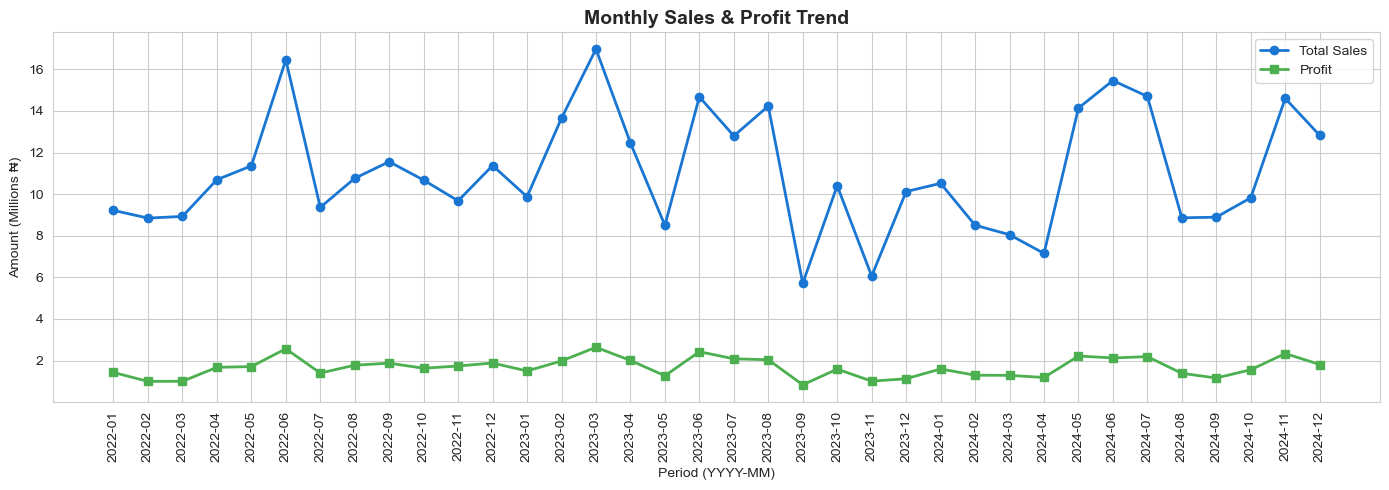

In [30]:
import matplotlib.pyplot as plt

# Group data
monthly = (
    hm_balanced.groupby(['Year','Month'])[['Total_Sales','Profit']]
    .sum()
    .reset_index()
    .sort_values(['Year','Month'])
)

# Create Period column (YYYY-MM)
monthly['Period'] = (
    monthly['Year'].astype(str) + '-' +
    monthly['Month'].astype(str).str.zfill(2)
)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly['Period'], monthly['Total_Sales']/1e6,
        marker='o', color='#1976D2', label='Total Sales', linewidth=2)

ax.plot(monthly['Period'], monthly['Profit']/1e6,
        marker='s', color='#4CAF50', label='Profit', linewidth=2)

ax.set_title('Monthly Sales & Profit Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Period (YYYY-MM)')
ax.set_ylabel('Amount (Millions ₦)')

ax.legend()

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



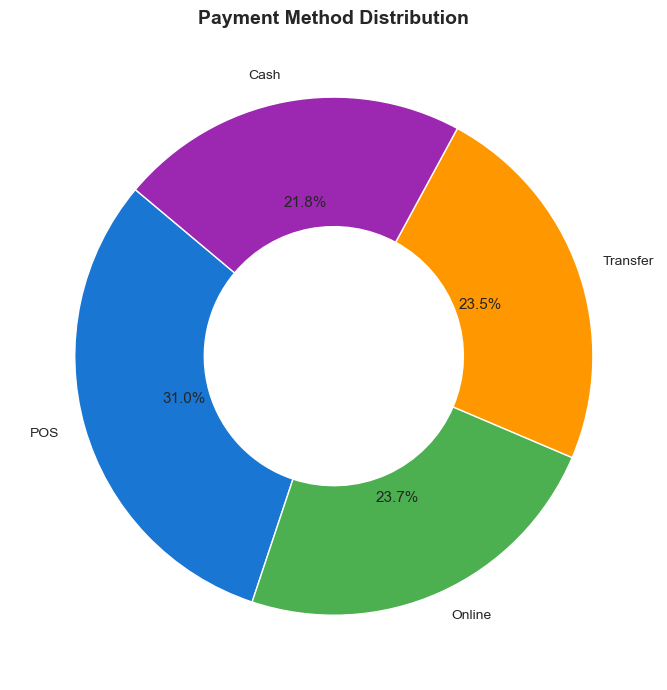

In [31]:
import matplotlib.pyplot as plt

# Correct assignment
pay_counts = hm_balanced['Payment_Method'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    pay_counts.values,
    labels=pay_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'width': 0.5},
    colors=['#1976D2','#4CAF50','#FF9800','#9C27B0']
)

# Format percentage text
for t in autotexts:
    t.set_fontsize(11)

ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



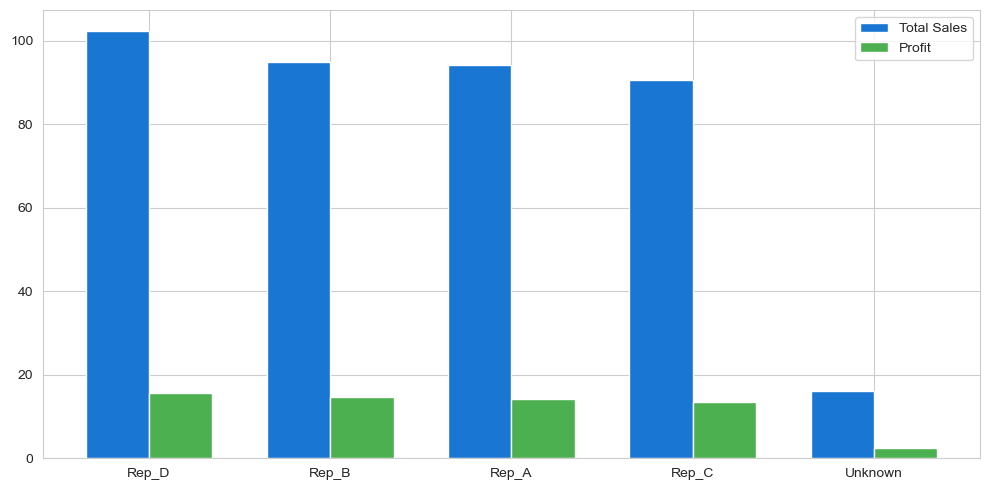

In [32]:
#sales rep performance
rep_perf = ( 
 hm_balanced.groupby('Sales_Rep')[['Total_Sales','Profit']] 
 .sum().sort_values('Total_Sales', ascending=False) ) 
fig, ax = plt.subplots(figsize=(10, 5)) 
x, w = np.arange(len(rep_perf)), 0.35 
ax.bar(x - w/2, rep_perf['Total_Sales']/1e6, width=w, label='Total Sales',  color='#1976D2') 
ax.bar(x + w/2, rep_perf['Profit']/1e6, width=w, label='Profit',  color='#4CAF50') 
ax.set_xticks(x) 
ax.set_xticklabels(rep_perf.index) 
# ax.set_title('Sales Rep Performance', fontsize=14, fontweight='bold') ax.set_ylabel('Amount (Millions ₦)') 
ax.legend() 
plt.tight_layout() 
plt.show() 


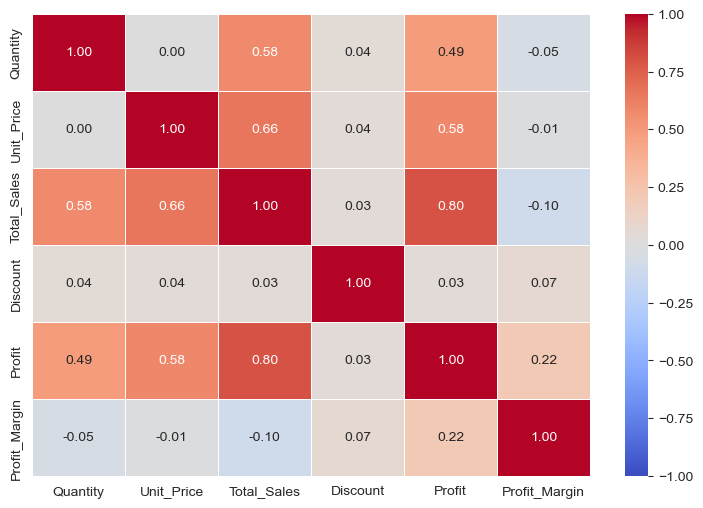

In [33]:
#correlation heatmap
corr = hm_balanced[['Quantity','Unit_Price','Total_Sales', 
 'Discount','Profit','Profit_Margin']].corr() 
fig, ax = plt.subplots(figsize=(9, 6)) 
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
 linewidths=0.5, ax=ax, vmin=-1, vmax=1) 
# ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold') plt.tight_layout() 
plt.show() 


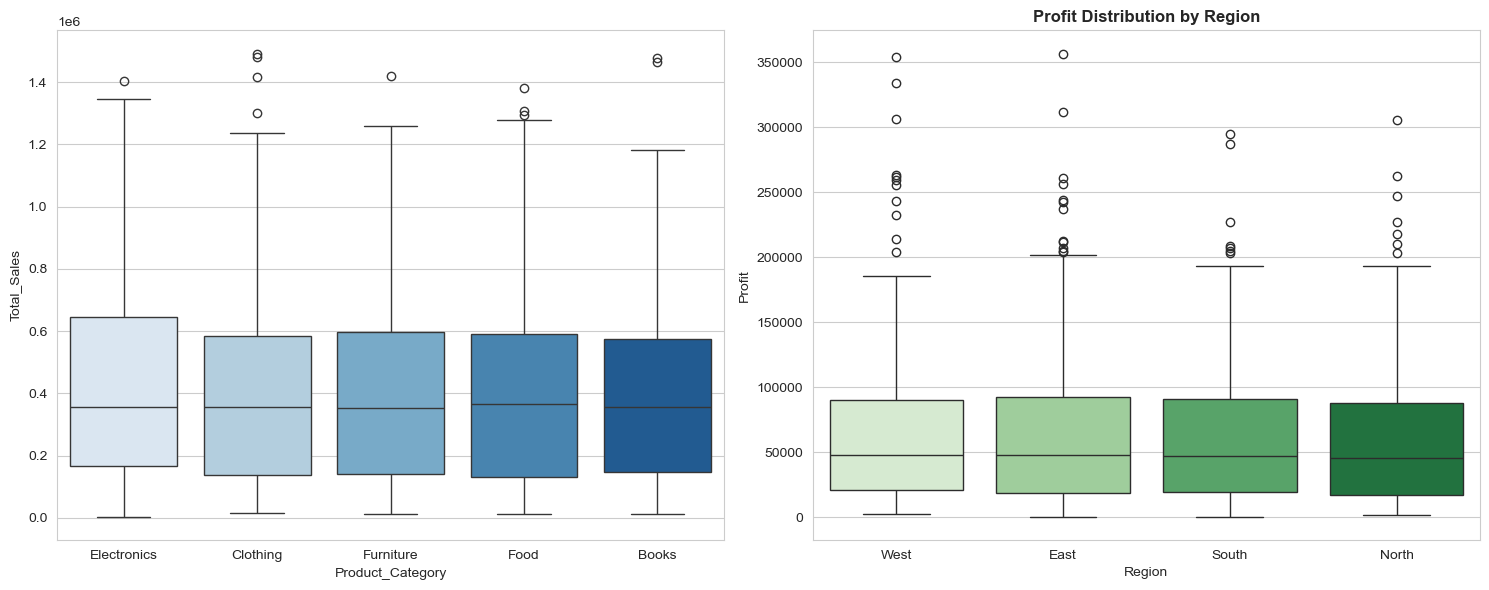

In [34]:
#sales by category region
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) 
sns.boxplot(data=hm_balanced, x='Product_Category', y='Total_Sales',  palette='Blues', ax=axes[0]) 
# axes[0].set_title('Sales Distribution by Category', fontweight='bold') axes[0].tick_params(axis='x', rotation=15) 
sns.boxplot(data=hm_balanced, x='Region', y='Profit', 
 palette='Greens', ax=axes[1]) 
axes[1].set_title('Profit Distribution by Region', fontweight='bold') 
plt.tight_layout() 
plt.show() 


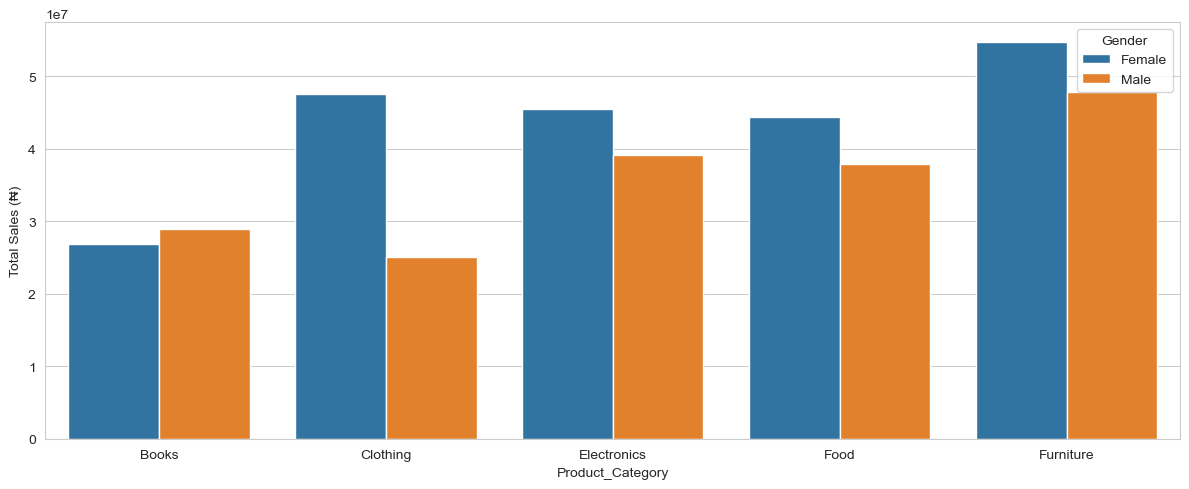

In [88]:
#sales by gender and product category
gender_cat = ( 
 hm_balanced.groupby(['Gender','Product_Category'])['Total_Sales']  .sum().reset_index() 
) 
fig, ax = plt.subplots(figsize=(12, 5)) 
sns.barplot(data=gender_cat, x='Product_Category', y='Total_Sales',  hue='Gender', )
 # palette={'Female':'#E91E63','Male':'#1976D2'}, ax=ax) ax.set_title('Sales by Product Category and Gender', fontsize=13,  fontweight='bold') 
ax.set_ylabel('Total Sales (₦)')
ax.legend(title='Gender') 
plt.tight_layout() 
plt.show()


In [35]:
# Monthly trend 
monthly_trend = ( 
 hm_balanced.groupby(['Year','Month'])[['Total_Sales','Profit']]  .sum().reset_index().sort_values(['Year','Month']) ) 
monthly_trend['Period'] = (monthly_trend['Year'].astype(str) + '-'  + monthly_trend['Month'].astype(str).str.zfill(2)) 
# Category summary 
cat_summary = hm_balanced.groupby('Product_Category').agg( 
 Total_Sales=('Total_Sales','sum'), 
 Profit=('Profit','sum'), 
 Orders=('Order_ID','count') 
).reset_index() 
# Region summary 
region_summary = hm_balanced.groupby('Region').agg( 
 Total_Sales=('Total_Sales','sum'), 
 Profit=('Profit','sum') 
).reset_index() 
# Sales Rep summary 
rep_summary = hm_balanced.groupby('Sales_Rep').agg( 
 Total_Sales=('Total_Sales','sum'), 
 Profit=('Profit','sum'), 
 Orders=('Order_ID','count') 
).reset_index() 
# Payment method 
# pay_summary = hm_balanced['Payment_Method'].value_counts().reset_index() pay_summary.columns = ['Payment_Method', 'Count'] 
print(' Summary tables ready!')


 Summary tables ready!


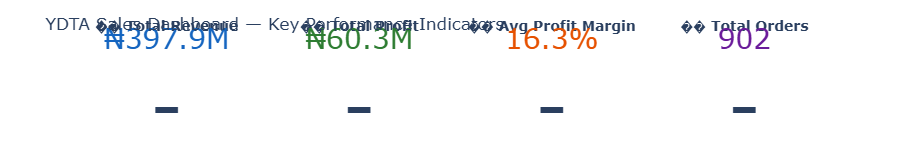

In [36]:
#KPI summary tiles
total_revenue = hm_balanced['Total_Sales'].sum() 
total_profit = hm_balanced['Profit'].sum() 
avg_margin = hm_balanced['Profit_Margin'].mean() 
total_orders = hm_balanced['Order_ID'].nunique() 
fig = go.Figure() 
kpis = [ 
 ('�� Total Revenue', f'₦{total_revenue/1e6:.1f}M', '#1565C0'),  ('�� Total Profit', f'₦{total_profit/1e6:.1f}M', '#2E7D32'),  ('�� Avg Profit Margin', f'{avg_margin:.1f}%', '#E65100'),  ('�� Total Orders', f'{total_orders:,}', '#6A1B9A'), ] 
for i, (label, value, color) in enumerate(kpis): 
 fig.add_trace(go.Indicator( 
 mode='number', 
 value=None, 
 title={'text': f'<b>{label}</b><br>' 
 f'<span style="font-size:28px;color:{color}">{value}</span>',  'font': {'size': 14}}, 
 domain={'row': 0, 'column': i} 
 )) 
fig.update_layout( 
 grid={'rows': 1, 'columns': 4}, 
 height=160, 
 title='YDTA Sales Dashboard — Key Performance Indicators', 
 margin={'t': 60, 'b': 10} 
) 
fig.show() 


In [47]:
pay_summary = (
    hm_balanced['Payment_Method']
    .value_counts()
    .reset_index()
)

pay_summary.columns = ['Payment_Method', 'Count']

In [48]:
print(pay_summary.head())

  Payment_Method  Count
0            POS    293
1         Online    224
2       Transfer    222
3           Cash    206


In [49]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        'Monthly Revenue & Profit Trend',
        'Sales by Product Category',
        'Revenue by Region',
        'Payment Method Share',
        'Sales Rep Performance',
        'Category vs Region Heatmap'
    ],
    specs=[[{'colspan': 2}, None], [{}, {}], [{}, {}]],
    vertical_spacing=0.10, horizontal_spacing=0.08
)

# Panel 1: Monthly Trend
fig.add_trace(
    go.Scatter(
        x=monthly_trend['Period'],
        y=monthly_trend['Total_Sales']/1e6,
        mode='lines+markers',
        name='Revenue (M₦)',
        line=dict(color='#1976D2', width=2)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly_trend['Period'],
        y=monthly_trend['Profit']/1e6,
        mode='lines+markers',
        name='Profit (M₦)',
        line=dict(color='#4CAF50', width=2, dash='dot')
    ),
    row=1, col=1
)

# Panel 3: Region Revenue
fig.add_trace(
    go.Bar(
        x=region_summary['Region'],
        y=region_summary['Total_Sales']/1e6,
        marker_color=['#1B5E20','#2E7D32','#388E3C','#43A047'],
        showlegend=False
    ),
    row=2, col=2
)

# Panel 4: Payment Method
fig.add_trace(
    go.Pie(
        labels=pay_summary['Payment_Method'],
        values=pay_summary['Count'],
        hole=0.4,
        marker=dict(colors=['#1976D2','#4CAF50','#FF9800','#9C27B0'])
    ),
    row=3, col=1
)

# Panel 5: Sales Rep
fig.add_trace(
    go.Bar(
        x=rep_summary['Sales_Rep'],
        y=rep_summary['Total_Sales']/1e6,
        name='Rep Revenue',
        marker_color='#1976D2',
        showlegend=False
    ),
    row=3, col=2
)

fig.add_trace(
    go.Bar(
        x=rep_summary['Sales_Rep'],
        y=rep_summary['Profit']/1e6,
        name='Rep Profit',
        marker_color='#4CAF50',
        showlegend=False
    ),
    row=3, col=2
)

fig.update_layout(
    height=1100,
    title_text='YDTA Sales Records — Interactive Dashboard',
    title_font_size=18,
    template='plotly_white'
)

fig.update_xaxes(tickangle=-45, row=1, col=1)

fig.show()

ValueError: Trace type 'pie' is not compatible with subplot type 'xy'
at grid position (3, 1)

See the docstring for the specs argument to plotly.subplots.make_subplots
for more information on subplot types

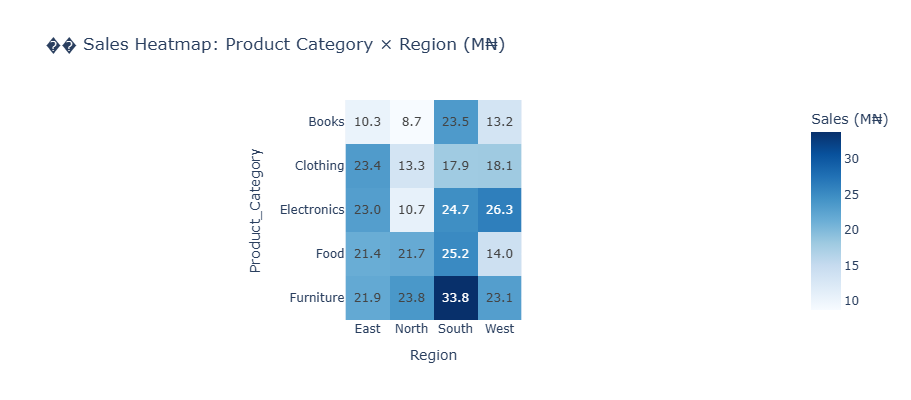

In [50]:
pivot = hm_balanced.pivot_table( 
 values='Total_Sales', index='Product_Category', 
 columns='Region', aggfunc='sum' 
) / 1e6 
fig = px.imshow( 
 pivot, text_auto='.1f', 
 color_continuous_scale='Blues', 
 title='�� Sales Heatmap: Product Category × Region (M₦)', 
 labels={'color': 'Sales (M₦)'} 
) 
fig.update_layout(height=400) 
fig.show() 


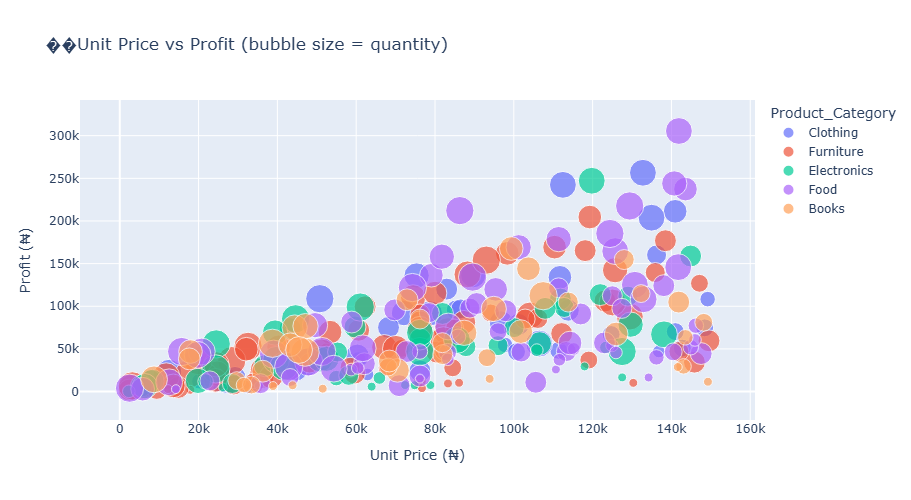

In [52]:
fig = px.scatter( 
 hm_balanced.sample(300, random_state=42), 
 x='Unit_Price', y='Profit', 
 color='Product_Category', 
 size='Quantity', 
 hover_data=['Customer_Name','Region','Sales_Rep'], 
 title='��Unit Price vs Profit (bubble size = quantity)', 
 labels={'Unit_Price':'Unit Price (₦)', 'Profit':'Profit (₦)'} ) 
fig.update_layout(height=500) 
fig.show()


In [53]:
output_path = 'sales_records_cleaned.xlsx' 
hm_balanced.to_excel(output_path, index=False) 
print(f' Cleaned dataset saved to: {output_path}') 
print(f' Final shape: {hm_balanced.shape[0]:,} rows × {hm_balanced.shape[1]}  columns')


 Cleaned dataset saved to: sales_records_cleaned.xlsx
 Final shape: 945 rows × 19  columns
